<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/brain_tumour_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile
import os
import shutil # Import shutil for directory removal

zip_path = "/content/drive/MyDrive/lgg-mri-segmentation.zip.zip"
extract_path = "/content/lgg_dataset"

# Force re-extraction by removing the existing directory if it exists
if os.path.exists(extract_path):
    print(f"Removing existing directory: {extract_path}")
    shutil.rmtree(extract_path)

print(f"Extracting {zip_path} to {extract_path}")
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Ready ✅")

Removing existing directory: /content/lgg_dataset
Extracting /content/drive/MyDrive/lgg-mri-segmentation.zip.zip to /content/lgg_dataset
Dataset Ready ✅


In [5]:
!pip install opencv-python
!pip install tensorflow
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split

import tensorflow as tf
from keras.models import Model
from keras.layers import *
from keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
import os
from glob import glob
import pandas as pd

def create_df(base_dir):
    image_paths = []
    mask_paths = []

    # Iterate through each patient directory
    # The patient directories are named like TCGA_...
    patient_folders = glob(os.path.join(base_dir, 'TCGA_*'))

    for patient_folder in patient_folders:
        # List all .tif files in the current patient folder
        all_files_in_folder = sorted(glob(os.path.join(patient_folder, '*.tif')))

        # Separate images and masks
        folder_images = {} # Map base_name (without .tif) to full path
        folder_masks = {}  # Map base_name (without _mask.tif) to full path

        for file_path in all_files_in_folder:
            filename = os.path.basename(file_path)
            if '_mask.tif' in filename:
                # This is a mask file, its base name for pairing is 'TCGA_..._X'
                base_name_for_pairing = filename.replace('_mask.tif', '')
                folder_masks[base_name_for_pairing] = file_path
            else:
                # This is an image file, its base name for pairing is 'TCGA_..._X'
                base_name_for_pairing = filename.replace('.tif', '')
                folder_images[base_name_for_pairing] = file_path

        # Pair them up
        for base_name, img_path in folder_images.items():
            if base_name in folder_masks:
                image_paths.append(img_path)
                mask_paths.append(folder_masks[base_name])

    df = pd.DataFrame({
        'images_paths': image_paths,
        'masks_paths': mask_paths
    })
    return df

# Correct base_dir based on zip file inspection
data_root_dir = "/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/" # This is the parent of patient folders
df = create_df(data_root_dir)
print("Total Samples:", len(df))
df.head()

# Inspection commands
print(f"\nContents of an example patient directory ({data_root_dir}TCGA_CS_4941_19960909/):")
!ls -F "{os.path.join(data_root_dir, 'TCGA_CS_4941_19960909')}"
print(f"\nContents of /content/lgg_dataset/ (recursive):\n")
!ls -R /content/lgg_dataset/


Streaming output truncated to the last 5000 lines.
TCGA_HT_7692_19960724_11.tif	   TCGA_HT_7692_19960724_20.tif
TCGA_HT_7692_19960724_12_mask.tif  TCGA_HT_7692_19960724_2_mask.tif
TCGA_HT_7692_19960724_12.tif	   TCGA_HT_7692_19960724_2.tif
TCGA_HT_7692_19960724_13_mask.tif  TCGA_HT_7692_19960724_3_mask.tif
TCGA_HT_7692_19960724_13.tif	   TCGA_HT_7692_19960724_3.tif
TCGA_HT_7692_19960724_14_mask.tif  TCGA_HT_7692_19960724_4_mask.tif
TCGA_HT_7692_19960724_14.tif	   TCGA_HT_7692_19960724_4.tif
TCGA_HT_7692_19960724_15_mask.tif  TCGA_HT_7692_19960724_5_mask.tif
TCGA_HT_7692_19960724_15.tif	   TCGA_HT_7692_19960724_5.tif
TCGA_HT_7692_19960724_16_mask.tif  TCGA_HT_7692_19960724_6_mask.tif
TCGA_HT_7692_19960724_16.tif	   TCGA_HT_7692_19960724_6.tif
TCGA_HT_7692_19960724_17_mask.tif  TCGA_HT_7692_19960724_7_mask.tif
TCGA_HT_7692_19960724_17.tif	   TCGA_HT_7692_19960724_7.tif
TCGA_HT_7692_19960724_18_mask.tif  TCGA_HT_7692_19960724_8_mask.tif
TCGA_HT_7692_19960724_18.tif	   TCGA_HT_7692_1996072

In [7]:
def split_df(df):
    train_df, dummy_df = train_test_split(df, train_size=0.8, random_state=42)
    valid_df, test_df = train_test_split(dummy_df, train_size=0.5, random_state=42)
    return train_df, valid_df, test_df

train_df, valid_df, test_df = split_df(df)

print(len(train_df), len(valid_df), len(test_df))

3143 393 393


In [8]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/lgg-mri-segmentation.zip.zip" # Corrected path based on successful extraction

# Check if the file exists before trying to open it
if not os.path.exists(zip_path):
    print(f"Error: The file {zip_path} does not exist. Please check the path.")
else:
    print(f"Contents of the zip file: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for file_info in zip_ref.infolist():
            print(file_info.filename)


Streaming output truncated to the last 5000 lines.
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7294_19890104/TCGA_DU_7294_19890104_9_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_1.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_13.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_13_mask.tif
lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_14.tif
lgg-mri-segmentation/kag

In [9]:
print("Recursive listing of /content/lgg_dataset/")
!ls -R /content/lgg_dataset/

Streaming output truncated to the last 5000 lines.
TCGA_HT_7692_19960724_11.tif	   TCGA_HT_7692_19960724_20.tif
TCGA_HT_7692_19960724_12_mask.tif  TCGA_HT_7692_19960724_2_mask.tif
TCGA_HT_7692_19960724_12.tif	   TCGA_HT_7692_19960724_2.tif
TCGA_HT_7692_19960724_13_mask.tif  TCGA_HT_7692_19960724_3_mask.tif
TCGA_HT_7692_19960724_13.tif	   TCGA_HT_7692_19960724_3.tif
TCGA_HT_7692_19960724_14_mask.tif  TCGA_HT_7692_19960724_4_mask.tif
TCGA_HT_7692_19960724_14.tif	   TCGA_HT_7692_19960724_4.tif
TCGA_HT_7692_19960724_15_mask.tif  TCGA_HT_7692_19960724_5_mask.tif
TCGA_HT_7692_19960724_15.tif	   TCGA_HT_7692_19960724_5.tif
TCGA_HT_7692_19960724_16_mask.tif  TCGA_HT_7692_19960724_6_mask.tif
TCGA_HT_7692_19960724_16.tif	   TCGA_HT_7692_19960724_6.tif
TCGA_HT_7692_19960724_17_mask.tif  TCGA_HT_7692_19960724_7_mask.tif
TCGA_HT_7692_19960724_17.tif	   TCGA_HT_7692_19960724_7.tif
TCGA_HT_7692_19960724_18_mask.tif  TCGA_HT_7692_19960724_8_mask.tif
TCGA_HT_7692_19960724_18.tif	   TCGA_HT_7692_1996072

In [10]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [30]:
def create_gens(df, aug_dict):
    img_size = (256,256)
    batch_size = 16

    img_gen = ImageDataGenerator(**aug_dict)
    msk_gen = ImageDataGenerator(**aug_dict)

    image_gen = img_gen.flow_from_dataframe(
        df, x_col='images_paths',
        class_mode=None, color_mode='rgb',
        target_size=img_size, batch_size=batch_size,
        seed=1, shuffle=False   # 🔥 IMPORTANT
    )

    mask_gen = msk_gen.flow_from_dataframe(
        df, x_col='masks_paths',
        class_mode=None, color_mode='grayscale',
        target_size=img_size, batch_size=batch_size,
        seed=1, shuffle=False   # 🔥 IMPORTANT
    )

    while True:   # 🔥 IMPORTANT
        img = next(image_gen) / 255.0
        msk = next(mask_gen) / 255.0

        msk = (msk > 0.5).astype(np.float32)

        yield img, msk

In [12]:
def unet(input_size=(256,256,3)):
    inputs = Input(input_size)

    c1 = Conv2D(64,3,activation='relu',padding='same')(inputs)
    c1 = Conv2D(64,3,activation='relu',padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128,3,activation='relu',padding='same')(p1)
    c2 = Conv2D(128,3,activation='relu',padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(256,3,activation='relu',padding='same')(p2)
    c3 = Conv2D(256,3,activation='relu',padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    c4 = Conv2D(512,3,activation='relu',padding='same')(p3)
    c4 = Conv2D(512,3,activation='relu',padding='same')(c4)
    p4 = MaxPooling2D()(c4)

    c5 = Conv2D(1024,3,activation='relu',padding='same')(p4)

    u6 = Conv2DTranspose(512,2,strides=2,padding='same')(c5)
    u6 = concatenate([u6,c4])
    c6 = Conv2D(512,3,activation='relu',padding='same')(u6)

    u7 = Conv2DTranspose(256,2,strides=2,padding='same')(c6)
    u7 = concatenate([u7,c3])
    c7 = Conv2D(256,3,activation='relu',padding='same')(u7)

    u8 = Conv2DTranspose(128,2,strides=2,padding='same')(c7)
    u8 = concatenate([u8,c2])
    c8 = Conv2D(128,3,activation='relu',padding='same')(u8)

    u9 = Conv2DTranspose(64,2,strides=2,padding='same')(c8)
    u9 = concatenate([u9,c1])
    c9 = Conv2D(64,3,activation='relu',padding='same')(u9)

    outputs = Conv2D(1,1,activation='sigmoid')(c9)

    return Model(inputs, outputs)

In [13]:
def dice_coef(y_true, y_pred):
  smooth = 1
  y_true_f = tf.reshape(y_true,[-1])
  y_pred_f = tf.reshape(y_pred,[-1])
  intersection = tf.reduce_sum(y_true_f * y_pred_f)
  return (2.*intersection + smooth)/(tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)+smooth)

def dice_loss(y_true,y_pred):
  return 1.0 - dice_coef(y_true,y_pred)

model = unet()

model.compile(optimizer=Adamax(learning_rate=0.001),
              loss = dice_loss,
              metrics =['accuracy',dice_coef]
              )
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_8[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1024)             │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │  4,719,104 │ concatenate[0][0

 Total params: 18,459,137 (70.42 MB)

 Trainable params: 18,459,137 (70.42 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
train_gen = create_gens(train_df, dict(horizontal_flip=True))
val_gen = create_gens(valid_df, {})

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_df)//16,
    validation_data=val_gen,
    validation_steps=len(valid_df)//16,
    epochs=30
)

Found 3143 validated image filenames.
Found 3143 validated image filenames.
Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.9900 - dice_coef: 1.2934e-04 - loss: 0.9999Found 393 validated image filenames.
Found 393 validated image filenames.
196/196 ━━━━━━━━━━━━━━━━━━━━ 149s 763ms/step - accuracy: 0.9894 - dice_coef: 1.3082e-04 - loss: 0.9999 - val_accuracy: 0.9919 - val_dice_coef: 0.0419 - val_loss: 0.9581
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 175s 643ms/step - accuracy: 0.9894 - dice_coef: 1.2353e-04 - loss: 0.9999 - val_accuracy: 0.9926 - val_dice_coef: 4.4429e-04 - val_loss: 0.9996
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 146s 744ms/step - accuracy: 0.9894 - dice_coef: 1.1548e-04 - loss: 0.9999 - val_accuracy: 0.9924 - val_dice_coef: 2.1569e-04 - val_loss: 0.9998
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 125s 640ms/step - accuracy: 0.9894 - dice_coef: 1.2633e-04 - loss: 0.9999 - val_accuracy: 0.9920 - val_dice_coef: 1.7844e-04 - val_loss: 0.9998
Epoch 5/30
196/196

In [17]:
model.save("/content/drive/MyDrive/unet_model.keras")
print("Model Saved ✅")

Model Saved ✅


In [18]:
def predicted_image(img_path):
  img = cv2.imread(img_path)
  img = cv2.resize(img,(256,256))
  img = img/255
  img = np.expand_dims(img,0)

  pred = model.predict(img)[0]
  return img[0],pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


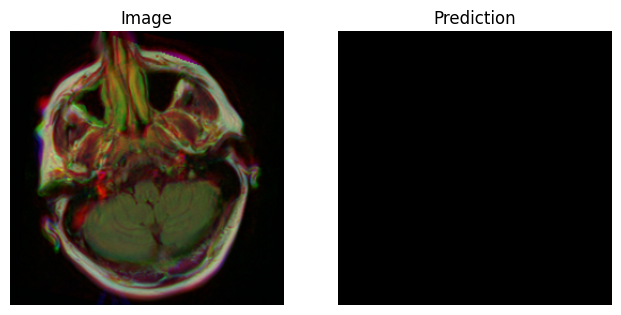

In [20]:
import random
idx = random.randint(0,len(test_df)-1)
img_path = test_df['images_paths'].iloc[idx]
mask_path = test_df['masks_paths'].iloc[idx]

img,pred = predicted_image(img_path)
true_mask = cv2.imread(mask_path,0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(pred>0.5,cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


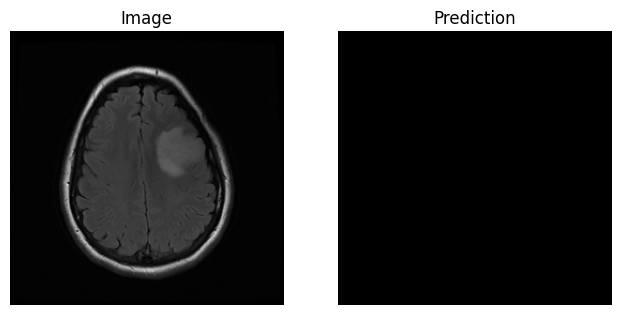

In [29]:
import random
idx = random.randint(56,len(test_df)-1)
img_path = test_df['images_paths'].iloc[idx]
mask_path = test_df['masks_paths'].iloc[idx]

img,pred = predicted_image(img_path)
true_mask = cv2.imread(mask_path,0)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(pred>0.5,cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.show()